3. MODELO DE COX
- El objetivo de esta sección es identificar qué variables clínicas influyen significativamente en la supervivencia, controlando por el efecto de las demás

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

luad = pd.read_csv("../data/tcga_luad_modelo.csv")
luad["estadio"] = pd.Categorical(luad["estadio"], categories=["I","II","III","IV"], ordered=True)
luad["grupo_edad"] = pd.Categorical(luad["grupo_edad"], categories=["<55","55-65","65-75",">75"], ordered=True)

print(f"Pacientes cargados: {len(luad)}")
luad.head()

Pacientes cargados: 509


,tiempo_anios,evento,estadio,age_at_index,grupo_edad,sexo,ajcc_pathologic_n,ajcc_pathologic_m,primary_diagnosis
0,2.836413,0,I,60.0,55-65,Mujer,N0,M0,"Adenocarcinoma, NOS"
1,1.993155,0,NaN,64.0,55-65,Hombre,NaN,NaN,Mucinous adenocarcinoma
2,0.380561,1,III,65.0,65-75,Mujer,N2,M0,Adenocarcinoma with mixed subtypes
3,1.409993,0,I,87.0,>75,Mujer,N0,MX,"Adenocarcinoma, NOS"
4,2.264203,0,II,60.0,55-65,Hombre,N0,MX,"Squamous cell carcinoma, NOS"


In [ ]:
#Para ajustar este tipo de modelo, primero hay que preparar las variables,
#ya que necesita números en lugar de texto
luad_cox = luad.dropna(subset=["estadio", "ajcc_pathologic_n", "ajcc_pathologic_m"]).copy()

luad_cox["estadio_num"] = luad_cox["estadio"].map({"I":1, "II": 2, "III": 3, "IV": 4})

#Variables dummies (binarias) para el sexo, y las categorías de estadificación N y M
luad_cox["sexo_hombre"] = (luad_cox["sexo"] == "Hombre").astype(int) #será 1 si es hombre, y 0 si es mujer

#Como hay valores NX y MX en cada categoría, que quieren decir "no evaluado", no metástasis,
#les daré un tratamiento diferente a las variables: solo tendrán valor 1 las que incluyan 
#estrictamente algún nivel de afección de ganglios (en el caso de N) o metástasis (en el caso de M)
#1, 2, 3, 1b y 1a son los observados en este conjunto de datos
luad_cox["n_positivo"] = (luad_cox["ajcc_pathologic_n"].isin(["N1", "N2", "N3"])).astype(int)
luad_cox["m_positivo"] = (luad_cox["ajcc_pathologic_m"].isin(["M1", "M1b", "M1a"])).astype(int)

print(f"Pacientes tras eliminar missing: {len(luad_cox)}")
print("\nDistribución N positivo:", luad_cox["n_positivo"].value_counts().to_dict())
print("\nDistribución M positivo:", luad_cox["m_positivo"].value_counts().to_dict())

Pacientes tras eliminar missing: 383

Distribución N positivo: {0: 263, 1: 120}

Distribución M positivo: {0: 363, 1: 20}


In [8]:
#3.1 MODELO DE COX UNIVARIANTE
#Primero ajusto un modelo separado para cada variable, y extraigo el HR y el valor p
variables = {
    "estadio_num": "Estadio TNM",
    "age_at_index": "Edad",
    "sexo_hombre": "Sexo (Hombre)",
    "n_positivo": "Ganglios (N+)",
    "m_positivo": "Metástasis (M+)"
}
resultados = []

#He localizado 5 missing values en la variable age_at_index, así que los voy a omitir en este paso para evitar errores
luad_cox = luad_cox.dropna(subset=["age_at_index"]).copy()
for var, nombre in variables.items():
    cph = CoxPHFitter()

    #Por cada iteración, ajusto un modelo con una variable de la lista + el tiempo de seguimiento y el evento
    cph.fit(
        luad_cox[["tiempo_anios", "evento", var]],
        duration_col="tiempo_anios",
        event_col="evento"
    )
    hr = cph.hazard_ratios_[var]
    ci_low, ci_high = cph.confidence_intervals_.loc[var]
    pval = cph.summary["p"][var]

    resultados.append({
        "Variable": nombre,
        "HR": round(hr, 3),
        "IC 95% inferior": round(np.exp(ci_low),2),
        "IC 95% superior": round(np.exp(ci_high),2),
        "p-valor": round(pval,4)
    })

resultados_df = pd.DataFrame(resultados)
print(resultados_df.to_string(index=False))


       Variable    HR  IC 95% inferior  IC 95% superior  p-valor
    Estadio TNM 1.663             1.35             2.05   0.0000
           Edad 1.006             0.99             1.02   0.4923
  Sexo (Hombre) 1.143             0.80             1.63   0.4612
  Ganglios (N+) 2.313             1.62             3.30   0.0000
Metástasis (M+) 2.581             1.38             4.84   0.0031


In [9]:
#3.2. MODELO MULTIVARIANTE
#Se analizan todas las variables juntas, para ver el efecto de cada una controlando por las demás
cph_multi = CoxPHFitter()

cols_modelo = [
    "tiempo_anios", "evento", "estadio_num", "age_at_index",
    "sexo_hombre", "n_positivo", "m_positivo"
]
cph_multi.fit(
    luad_cox[cols_modelo],
    duration_col="tiempo_anios",
    event_col="evento"
)
cph_multi.print_summary()

<lifelines.CoxPHFitter: fitted with 378 total observations, 256 right-censored observations>
             duration col = 'tiempo_anios'
                event col = 'evento'
      baseline estimation = breslow
   number of observations = 378
number of events observed = 122
   partial log-likelihood = -601.33
         time fit was run = 2026-09-26 15:17:04 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
estadio_num   0.49      1.63      0.17            0.15            0.83                1.16                2.30
age_at_index  0.01      1.01      0.01           -0.01            0.03                0.99                1.03
sexo_hombre   0.00      1.00      0.19           -0.36            0.37                0.70                1.44
n_positivo    0.22      1.24      0.28           -0.33            0.76                0.72                2.15
m_positivo    1.32      3.74      0.36            0.61            2.03                1.84                7.60

              cmp to    z      p  -log2(p)
covariate                                 
estadio_num     0.00 2.83 <0.005      7.75
age_at_index    0.00 0.84   0.40      1.33
sexo_hombre     0.00 0.01   0.99      0.02
n_positivo      0.00 0.77   0.44      1.19
m_positivo      0.00 3.66 <0.005     11.93
---
Concordance = 0.67
Partial AIC = 1212.67
log-likelihood ratio test = 34.61 on 5 df
-log2(p) of ll-ratio test = 19.08

In [10]:
#3.3 VALIDACIÓN DE ASUNCIÓN de proporcionalidad de hazards
#Aquí implemento el test de Schoenfeld, según el que si p>0.05 para una variable, la asunción se cumplirá
from lifelines.statistics import proportional_hazard_test

results_ph = proportional_hazard_test(
    cph_multi,
    luad_cox[cols_modelo],
    time_transform="rank"
)
results_ph.print_summary()

In [16]:
#3.3.1 Corrección del análisis multivariante
#Debido al incumplimiento de la asunción sobre la variable estadio,
#voy a corregir el modelo multivariante, añadiendo esta variable como estratificada
#en lugar de covariable.
cph_multi = CoxPHFitter()

luad_cox_strata = luad_cox.copy()
luad_cox_strata["estadio_str"] = luad_cox_strata["estadio"].astype(str)

cols_multi = ["tiempo_anios", "evento", "estadio_str", 
              "age_at_index", "sexo_hombre", "n_positivo", "m_positivo"]

cph_multi.fit(
    luad_cox_strata[cols_multi],
    duration_col="tiempo_anios",
    event_col="evento",
    strata=["estadio_str"]  # estadio como estrato
)

cph_multi.print_summary()

<lifelines.CoxPHFitter: fitted with 378 total observations, 256 right-censored observations>
             duration col = 'tiempo_anios'
                event col = 'evento'
                   strata = estadio_str
      baseline estimation = breslow
   number of observations = 378
number of events observed = 122
   partial log-likelihood = -471.90
         time fit was run = 2026-09-26 15:51:03 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
age_at_index  0.01      1.01      0.01           -0.01            0.03                0.99                1.03
sexo_hombre  -0.01      0.99      0.19           -0.38            0.36                0.69                1.43
n_positivo    0.07      1.07      0.30           -0.51            0.64                0.60                1.91
m_positivo    1.59      4.93      0.39            0.84            2.35                2.32               10.48

              cmp to     z      p  -log2(p)
covariate                                  
age_at_index    0.00  0.95   0.34      1.55
sexo_hombre     0.00 -0.05   0.96      0.06
n_positivo      0.00  0.22   0.83      0.28
m_positivo      0.00  4.14 <0.005     14.83
---
Concordance = 0.59
Partial AIC = 951.80
log-likelihood ratio test = 16.04 on 4 df
-log2(p) of ll-ratio test = 8.40

In [ ]:
#3.3.2 Segunda validación del modelo, ahora estratificado
results_ph2 = proportional_hazard_test(
    cph_multi,
    luad_cox_strata[cols_multi],
    time_transform="rank"
)
results_ph2.print_summary()

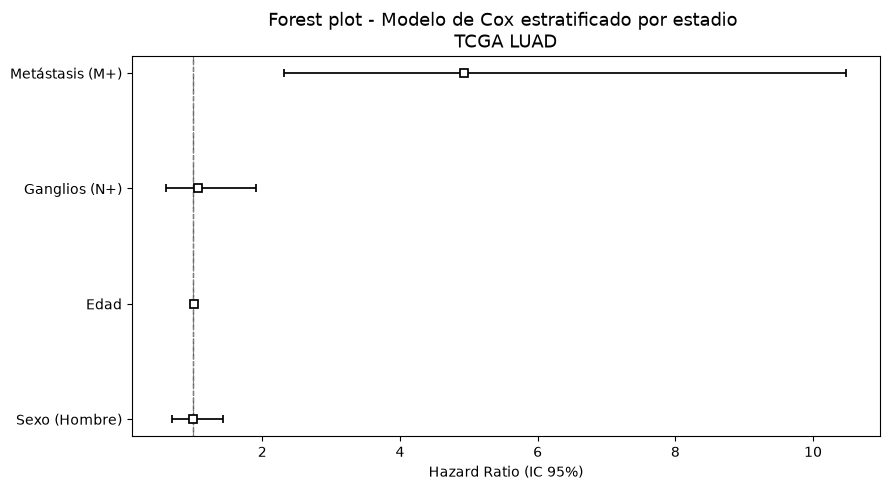

In [18]:
#3.4 VISUALIZACIÓN
#Forest plot de los hazard ratios del modelo estratificado
fig, ax = plt.subplots(figsize=(9,5))

cph_multi.plot(ax=ax, hazard_ratios=True)

ax.axvline(1, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Forest plot - Modelo de Cox estratificado por estadio \nTCGA LUAD", fontsize=13)
ax.set_xlabel("Hazard Ratio (IC 95%)")
ax.set_ylabel("")

labels = {
    "age_at_index": "Edad",
    "sexo_hombre": "Sexo (Hombre)",
    "n_positivo": "Ganglios (N+)",
    "m_positivo": "Metástasis (M+)"
}
#devuelve la traducción del texto de las etiquetas actuales del eje y,
#en función de los valores del diccionario "labels"
ax.set_yticklabels([
    labels.get(t.get_text(), t.get_text()) 
    for t in ax.get_yticklabels()
])
plt.tight_layout()
plt.savefig("../figures/forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()